In [1]:
!pip install shap imbalanced-learn xgboost scikit-learn pandas numpy

## Imports

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.base import clone

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # for SMOTE inside CV folds

from xgboost import XGBClassifier
import shap

print('All packages imported successfully.')

All packages imported successfully.


## Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# In Colab: adjust HERE to point at your Drive folder
# HERE = Path('/content/drive/MyDrive/MS&E 125 Project')
HERE = Path('/content/drive/MyDrive/1. MS&E 125/MS&E 125 Project/Full Model Comparison')  # default: same folder as notebook

df_train = pd.read_csv(HERE / 'training_named_cities.csv')
df_val   = pd.read_csv(HERE / 'validation_named_cities.csv')
df_test  = pd.read_csv(HERE / 'testing_named_cities.csv')

for df in (df_train, df_val, df_test):
    df['tract_id'] = df['tract_id'].astype(str).str.zfill(11)

print(f'Train : {df_train.shape}  —  years: {sorted(df_train["year"].unique())}')
print(f'Val   : {df_val.shape}   —  years: {sorted(df_val["year"].unique())}')
print(f'Test  : {df_test.shape}  —  years: {sorted(df_test["year"].unique())}')

Train : (696, 41)  —  years: [np.int64(2010), np.int64(2015)]
Val   : (348, 41)   —  years: [np.int64(2020)]
Test  : (344, 37)  —  years: [np.int64(2024)]


## Feature Engineering

**Change-feature design (no leakage):**

| Split | Earlier | Later | Features | Label |
|-------|---------|-------|----------|-------|
| Train | 2010 | 2015 | 2010→2015 changes | 2010→2015 gentrification |
| Val   | 2015 | 2020 | 2015→2020 changes | 2015→2020 gentrification |
| Test  | 2020 | 2024 | 2020→2024 changes | unknown (predicting) |

For each split, the earlier snapshot is already historical by prediction time — no future data leaks in.

**FIX vs v1:** `jan_housing_value_begin` / `jan_housing_value_end` (Zillow) are removed from `PIVOT_FEATS`. These columns are correlated with the gentrification label by construction (both measure housing appreciation over the same period), creating a circular feature–label relationship.

In [5]:
PIVOT_FEATS = [
    'population', 'median_income', 'median_rent', 'median_home_value',
    'share_college', 'share_25_34', 'homeownership_rate', 'vacancy_rate',
    'share_pre1940', 'share_white', 'share_black', 'share_hispanic',
    'poverty_rate', 'rent_burden', 'jobs_arts', 'jobs_food', 'jobs_total',
    'arts_density', 'food_density', 'gentrify_density',
    'arts_job_share', 'food_job_share',
    # jan_housing_value_begin / jan_housing_value_end intentionally excluded:
    # Zillow-sourced and correlated with the gentrification label by construction.
    'single_family', 'multifamily', 'commercial', 'industrial',
    'civic_other', 'total_permit_count',
]

# These four features define the gentrification label (income, rent, home value, education).
# Their delta/pct changes would be circular, so we include only their snapshot levels.
LEVEL_ONLY_FEATS = ['median_income', 'median_rent', 'median_home_value', 'share_college']

STATIC_FEATS = ['city_sf', 'city_oakland', 'city_san_jose']


def build_features(later_df, earlier_df, pivot_feats, static_feats, target_col=None, level_only_feats=None):
    """
    Build one-row-per-tract features from two time-point DataFrames.

    For each feature f produces:
      f        — level at the LATER time point
      delta_f  — later - earlier  (absolute change)  [skipped for level_only_feats]
      pct_f    — delta / earlier  (% change)          [skipped for level_only_feats]

    Parameters
    ----------
    later_df         : DataFrame with the more recent snapshot (must have 'tract_id')
    earlier_df       : DataFrame with the older snapshot (must have 'tract_id')
    pivot_feats      : columns to compute levels + deltas for
    static_feats     : columns to carry forward from later_df only (no delta computed)
    target_col       : if provided and present in later_df, adds the label column
    level_only_feats : features for which only the snapshot level is included;
                       delta/pct are skipped to avoid circular feature-label relationships

    Returns
    -------
    DataFrame indexed by tract_id, NAs filled with column medians
    """
    level_only = set(level_only_feats or [])

    later   = later_df.set_index('tract_id').copy()
    earlier = earlier_df.set_index('tract_id').copy()
    shared  = later.index.intersection(earlier.index)
    later_s   = later.loc[shared]
    earlier_s = earlier.loc[shared]

    rows = {}
    for f in pivot_feats:
        if f in later_s.columns:
            rows[f] = later_s[f]
    for f in static_feats:
        if f in later_s.columns:
            rows[f] = later_s[f]
    for f in pivot_feats:
        if f in level_only:
            continue  # snapshot level already added above; skip delta/pct
        if f in later_s.columns and f in earlier_s.columns:
            delta = later_s[f] - earlier_s[f]
            rows[f'delta_{f}'] = delta
            base = earlier_s[f]
            if (base > 0).all():
                rows[f'pct_{f}'] = delta / base
    if target_col and target_col in later_s.columns:
        rows[target_col] = later_s[target_col]

    out = pd.DataFrame(rows, index=shared)
    out.index.name = 'tract_id'
    return out.fillna(out.median())


# Build feature matrices
train_2015 = df_train[df_train['year'] == 2015]
train_2010 = df_train[df_train['year'] == 2010]

df_tr = build_features(train_2015, train_2010, PIVOT_FEATS, STATIC_FEATS, target_col='gentrified', level_only_feats=LEVEL_ONLY_FEATS)
df_vl = build_features(df_val,     train_2015, PIVOT_FEATS, STATIC_FEATS, target_col='gentrified', level_only_feats=LEVEL_ONLY_FEATS)
df_te = build_features(df_test,    df_val,     PIVOT_FEATS, STATIC_FEATS,                          level_only_feats=LEVEL_ONLY_FEATS)

print(f'Feature matrix shapes:')
print(f'  Train : {df_tr.shape}  positives={int(df_tr["gentrified"].sum())}')
print(f'  Val   : {df_vl.shape}  positives={int(df_vl["gentrified"].sum())}')
print(f'  Test  : {df_te.shape}')

FEAT_COLS = [c for c in df_tr.columns if c != 'gentrified']
print(f'\nTotal features: {len(FEAT_COLS)}')
print('Sample features:', FEAT_COLS[:6], '...')

Feature matrix shapes:
  Train : (348, 62)  positives=8
  Val   : (348, 64)  positives=17
  Test  : (341, 63)

Total features: 61
Sample features: ['population', 'median_income', 'median_rent', 'median_home_value', 'share_college', 'share_25_34'] ...


## Scale Features

In [6]:
X_train = df_tr[FEAT_COLS].values
y_train = df_tr['gentrified'].values.astype(int)
X_val   = df_vl[FEAT_COLS].values
y_val   = df_vl['gentrified'].values.astype(int)
X_test  = df_te[FEAT_COLS].values

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit only on training
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f'X_train_s : {X_train_s.shape}  —  {y_train.sum()} pos / {(y_train==0).sum()} neg')
print(f'X_val_s   : {X_val_s.shape}  —  {y_val.sum()} pos / {(y_val==0).sum()} neg')
print(f'X_test_s  : {X_test_s.shape}')

X_train_s : (348, 61)  —  8 pos / 340 neg
X_val_s   : (348, 61)  —  17 pos / 331 neg
X_test_s  : (341, 61)


## SMOTE — for LASSO Feature Selection and Final Model Fitting Only

**FIX vs v1:** SMOTE is applied here only to produce a balanced training set for LASSO feature selection and final model fitting. For cross-validation, SMOTE is applied *inside* each fold via `imblearn.Pipeline` (see CV cells below) — this prevents synthetic validation samples from inflating CV AUC.

In [7]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_sm, y_sm = smote.fit_resample(X_train_s, y_train)

print(f'Before SMOTE — positives: {y_train.sum()}, negatives: {(y_train==0).sum()}')
print(f'After  SMOTE — positives: {y_sm.sum()}, negatives: {(y_sm==0).sum()}')
print()
print('Note: This balanced set is used for LASSO feature selection and final model fitting.')
print('CV uses SMOTE inside each fold (see below).')

Before SMOTE — positives: 8, negatives: 340
After  SMOTE — positives: 340, negatives: 340

Note: This balanced set is used for LASSO feature selection and final model fitting.
CV uses SMOTE inside each fold (see below).


## LASSO Feature Selection

In [8]:
lasso_cv = LogisticRegressionCV(
    Cs=np.logspace(-4, 2, 30),
    penalty='l1',
    solver='saga',
    cv=5,
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=5000,
    random_state=42
)
lasso_cv.fit(X_sm, y_sm)

coef = pd.Series(lasso_cv.coef_[0], index=FEAT_COLS)
SELECTED_FEATURES = coef[coef != 0].index.tolist()

print(f'Best regularisation strength C: {lasso_cv.C_[0]:.5f}')
print(f'Features selected: {len(SELECTED_FEATURES)} / {len(FEAT_COLS)}')
print()
print('Selected features (sorted by |coefficient|):')
for feat, val in coef[coef != 0].sort_values(key=abs, ascending=False).items():
    direction = '↑ higher value → more risk' if val > 0 else '↓ higher value → less risk'
    print(f'  {feat:45s}  {val:+.4f}  ({direction})')

sel_idx  = [FEAT_COLS.index(f) for f in SELECTED_FEATURES]
X_tr_sel = X_train_s[:, sel_idx]
X_vl_sel = X_val_s[:,   sel_idx]
X_te_sel = X_test_s[:,  sel_idx]
X_sm_sel = X_sm[:,      sel_idx]

Best regularisation strength C: 2.21222
Features selected: 44 / 61

Selected features (sorted by |coefficient|):
  delta_food_density                             -4.0304  (↓ higher value → less risk)
  arts_job_share                                 -3.5801  (↓ higher value → less risk)
  delta_food_job_share                           +3.0547  (↑ higher value → more risk)
  city_oakland                                   -2.8665  (↓ higher value → less risk)
  delta_jobs_food                                -2.3311  (↓ higher value → less risk)
  jobs_food                                      +1.9714  (↑ higher value → more risk)
  city_san_jose                                  +1.9292  (↑ higher value → more risk)
  delta_vacancy_rate                             -1.8583  (↓ higher value → less risk)
  pct_share_white                                +1.8569  (↑ higher value → more risk)
  delta_share_25_34                              +1.8132  (↑ higher value → more risk)
  pct_rent_burden

## Logistic Regression — Fit on Selected Features

In [9]:
lr = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    class_weight='balanced',
    max_iter=3000,
    random_state=42
)
lr.fit(X_sm_sel, y_sm)

val_proba_lr = lr.predict_proba(X_vl_sel)[:, 1]
val_auc_lr   = roc_auc_score(y_val, val_proba_lr)
print(f'LR held-out validation AUC: {val_auc_lr:.4f}')
print()
print('Classification report (validation):')
print(classification_report(y_val, lr.predict(X_vl_sel)))

LR held-out validation AUC: 0.5872

Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.87      0.91       331
           1       0.06      0.18      0.09        17

    accuracy                           0.83       348
   macro avg       0.51      0.52      0.50       348
weighted avg       0.91      0.83      0.87       348



## Cross-Validation — SMOTE Inside Each Fold (Leakage-Free)

**FIX vs v1:** The original notebook:
1. Applied SMOTE to the full training set before CV
2. Stacked train + val data for CV (`X_tv = np.vstack([X_tr_sel, X_vl_sel])`)

Both inflate CV AUC — SMOTE creates synthetic samples that share characteristics with held-out fold members, and including val data means the model "sees" the val set during CV.

**Fix:** Use `imblearn.Pipeline` so SMOTE is fit and applied only to the training portion of each fold. CV is restricted to `X_tr_sel` / `y_train` only.

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# imblearn Pipeline: SMOTE applied inside each fold to training portion only
pipe_lr_cv = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf',   LogisticRegression(
                  penalty='l2', C=1.0, solver='lbfgs',
                  class_weight='balanced', max_iter=3000, random_state=42))
])

cv_scores_lr = cross_val_score(
    pipe_lr_cv, X_tr_sel, y_train,   # training data ONLY
    cv=skf, scoring='roc_auc'
)

print(f'LR 5-fold CV AUC (SMOTE inside folds, training only):')
print(f'  Mean : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'  Folds: {np.round(cv_scores_lr, 4)}')

LR 5-fold CV AUC (SMOTE inside folds, training only):
  Mean : 0.6926 ± 0.1756
  Folds: [0.5441 0.4779 0.6471 0.9118 0.8824]


## Platt Scaling — Calibrate Probabilities

In [11]:
raw_val_proba = lr.predict_proba(X_vl_sel)[:, 1].reshape(-1, 1)

platt_scaler = LogisticRegression()
platt_scaler.fit(raw_val_proba, y_val)

def calibrated_proba(X_sel):
    """Return Platt-calibrated probabilities for the positive class."""
    raw = lr.predict_proba(X_sel)[:, 1].reshape(-1, 1)
    return platt_scaler.predict_proba(raw)[:, 1]

val_auc_cal = roc_auc_score(y_val, calibrated_proba(X_vl_sel))
print(f'Calibrated LR val AUC : {val_auc_cal:.4f}')
print(f'(Raw LR val AUC was   : {val_auc_lr:.4f})')

Calibrated LR val AUC : 0.5872
(Raw LR val AUC was   : 0.5872)


## Random Forest

In [12]:
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_sm_sel, y_sm)

val_auc_rf = roc_auc_score(y_val, rf.predict_proba(X_vl_sel)[:, 1])
print(f'RF held-out validation AUC: {val_auc_rf:.4f}')
print()
print('Classification report (validation):')
print(classification_report(y_val, rf.predict(X_vl_sel)))

RF held-out validation AUC: 0.5968

Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       331
           1       0.00      0.00      0.00        17

    accuracy                           0.95       348
   macro avg       0.48      0.50      0.49       348
weighted avg       0.90      0.95      0.93       348



## Random Forest — Cross-Validation (SMOTE Inside Folds)

In [13]:
pipe_rf_cv = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf',   RandomForestClassifier(
                  n_estimators=200, max_depth=8, min_samples_leaf=5,
                  class_weight='balanced_subsample', random_state=42, n_jobs=-1))
])

cv_scores_rf = cross_val_score(
    pipe_rf_cv, X_tr_sel, y_train,
    cv=skf, scoring='roc_auc'
)

print(f'RF 5-fold CV AUC (SMOTE inside folds, training only):')
print(f'  Mean : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print(f'  Folds: {np.round(cv_scores_rf, 4)}')

RF 5-fold CV AUC (SMOTE inside folds, training only):
  Mean : 0.5824 ± 0.2605
  Folds: [0.4412 0.8015 0.2721 0.9706 0.4265]


## SHAP Values — Random Forest

In [14]:
explainer_rf = shap.TreeExplainer(rf)
shap_vals_rf = explainer_rf.shap_values(X_te_sel)

sv_rf = shap_vals_rf[..., 1] if shap_vals_rf.ndim == 3 else shap_vals_rf

global_shap_rf = pd.DataFrame({
    'feature':       SELECTED_FEATURES,
    'mean_abs_shap': np.abs(sv_rf).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Global RF SHAP importance (test set):')
print(global_shap_rf.to_string(index=False))

Global RF SHAP importance (test set):
                 feature  mean_abs_shap
             share_black       0.056680
           city_san_jose       0.052202
    delta_food_job_share       0.030683
       delta_civic_other       0.030515
        delta_population       0.026911
          pct_population       0.023514
            city_oakland       0.020708
           single_family       0.020631
               jobs_food       0.019990
           share_pre1940       0.019302
  delta_gentrify_density       0.018899
       delta_share_black       0.018162
          food_job_share       0.017379
      delta_vacancy_rate       0.016701
             share_white       0.016388
          arts_job_share       0.016299
         pct_rent_burden       0.015567
    delta_arts_job_share       0.014300
     delta_share_pre1940       0.013170
       delta_share_25_34       0.009083
           median_income       0.008458
             median_rent       0.007827
             rent_burden       0.007767
  

## XGBoost — Hyperparameter Search

**FIX vs v1:** XGBoost uses `scale_pos_weight = n_neg / n_pos` instead of SMOTE. This is XGBoost's native mechanism for handling class imbalance and avoids any synthetic data. CV is run on the original (unbalanced) training data with `scale_pos_weight` handling imbalance internally.

In [15]:
n_pos = int(y_train.sum())
n_neg = int((y_train == 0).sum())
spw   = n_neg / n_pos
print(f'scale_pos_weight = {n_neg}/{n_pos} = {spw:.2f}')

param_dist = {
    'n_estimators':     [100, 200, 300, 500],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.01, 0.05, 0.1, 0.2],
    'subsample':        [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'gamma':            [0, 0.1, 0.2, 0.5],
    'reg_alpha':        [0, 0.01, 0.1, 1.0],
    'reg_lambda':       [1, 2, 5, 10],
}

base_xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=spw,   # handles imbalance natively — no SMOTE needed
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

search = RandomizedSearchCV(
    base_xgb, param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search.fit(X_tr_sel, y_train)   # training data only; no SMOTE

print(f'\nBest XGBoost CV AUC : {search.best_score_:.4f}')
print(f'Best params         : {search.best_params_}')

scale_pos_weight = 340/8 = 42.50
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best XGBoost CV AUC : 0.7926
Best params         : {'subsample': 0.7, 'reg_lambda': 10, 'reg_alpha': 0.01, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 0.6}


## XGBoost — Fit Best Model & Evaluate

In [16]:
xgb_model = XGBClassifier(
    **search.best_params_,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(
    X_tr_sel, y_train,
    eval_set=[(X_vl_sel, y_val)],
    verbose=False
)

val_prob_xgb = xgb_model.predict_proba(X_vl_sel)[:, 1]
val_auc_xgb  = roc_auc_score(y_val, val_prob_xgb)

print(f'XGBoost held-out val AUC: {val_auc_xgb:.4f}')
print()
print('Classification report (validation):')
print(classification_report(y_val, xgb_model.predict(X_vl_sel)))

XGBoost held-out val AUC: 0.6336

Classification report (validation):
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       331
           1       0.00      0.00      0.00        17

    accuracy                           0.95       348
   macro avg       0.48      0.50      0.49       348
weighted avg       0.90      0.95      0.92       348



In [17]:
# ── CV Std for XGBoost ─────────────────────────────────────────────────────────
xgb_cv = XGBClassifier(
    **search.best_params_,
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=spw,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_scores_xgb = cross_val_score(xgb_cv, X_tr_sel, y_train, cv=skf, scoring='roc_auc')

print(f'XGBoost CV AUC  : {cv_scores_xgb.mean():.4f}')
print(f'XGBoost CV Std  : ±{cv_scores_xgb.std():.4f}')
print(f'XGBoost CV folds: {cv_scores_xgb.round(4)}')

XGBoost CV AUC  : 0.7926
XGBoost CV Std  : ±0.1592
XGBoost CV folds: [0.4926 0.9118 0.8971 0.8971 0.7647]


## SHAP Values — XGBoost

In [18]:
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_vals_xgb = explainer_xgb.shap_values(X_te_sel)
sv_xgb = shap_vals_xgb[..., 1] if shap_vals_xgb.ndim == 3 else shap_vals_xgb

global_shap_xgb = pd.DataFrame({
    'feature':       SELECTED_FEATURES,
    'mean_abs_shap': np.abs(sv_xgb).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Global XGBoost SHAP importance (test set):')
print(global_shap_xgb.head(15).to_string(index=False))

Global XGBoost SHAP importance (test set):
               feature  mean_abs_shap
     delta_share_black       1.561731
        pct_population       1.037661
  delta_food_job_share       0.778245
         share_pre1940       0.762066
     delta_share_25_34       0.589003
       pct_rent_burden       0.561837
          poverty_rate       0.559080
     delta_share_white       0.451860
      delta_population       0.422944
  delta_share_hispanic       0.386195
    delta_food_density       0.340025
      delta_jobs_total       0.336949
delta_gentrify_density       0.303824
           share_black       0.233032
    delta_vacancy_rate       0.214070


## Apply All Models to Test Set — 3-Model Ensemble

In [19]:
lr_prob   = calibrated_proba(X_te_sel)
rf_prob   = rf.predict_proba(X_te_sel)[:, 1]
xgb_prob  = xgb_model.predict_proba(X_te_sel)[:, 1]
ensemble3 = (lr_prob + rf_prob + xgb_prob) / 3

# Ensemble validation AUC
ens_val     = (calibrated_proba(X_vl_sel) + rf.predict_proba(X_vl_sel)[:, 1] + val_prob_xgb) / 3
val_auc_ens = roc_auc_score(y_val, ens_val)

# Build output table
out = pd.DataFrame({'tract_id': df_te.index})
out['city']           = df_test.set_index('tract_id').reindex(df_te.index)['city'].values
out['lr_risk_score']  = np.round(lr_prob,   4)
out['rf_risk_score']  = np.round(rf_prob,   4)
out['xgb_risk_score'] = np.round(xgb_prob,  4)
out['risk_score']     = np.round(ensemble3, 4)  # PRIMARY — use this for mapping

out['risk_tier'] = pd.cut(
    ensemble3,
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Very High']
)

# Top SHAP driver per tract (XGBoost)
top_idx = np.argmax(np.abs(sv_xgb), axis=1)
out['top_risk_driver']  = [SELECTED_FEATURES[i] for i in top_idx]
out['driver_direction'] = [
    '↑ increases risk' if sv_xgb[r, c] > 0 else '↓ decreases risk'
    for r, c in enumerate(top_idx)
]

out_sorted = out.sort_values('risk_score', ascending=False).reset_index(drop=True)

print('Top 20 highest-risk tracts:')
print(out_sorted[['tract_id', 'city', 'risk_score', 'risk_tier',
                   'top_risk_driver', 'driver_direction']].head(20).to_string(index=False))

print('\nTier counts:')
print(out_sorted['risk_tier'].value_counts().to_dict())

Top 20 highest-risk tracts:
   tract_id          city  risk_score risk_tier   top_risk_driver driver_direction
06001403100       Oakland      0.2364       Low delta_share_black ↑ increases risk
06001406000       Oakland      0.1872       Low   pct_rent_burden ↓ decreases risk
06075017700 San Francisco      0.1809       Low delta_share_black ↓ decreases risk
06001401100       Oakland      0.1770       Low   pct_rent_burden ↓ decreases risk
06085505203      San Jose      0.1635       Low     share_pre1940 ↓ decreases risk
06085503804      San Jose      0.1542       Low    pct_population ↓ decreases risk
06085503312      San Jose      0.1429       Low     share_pre1940 ↓ decreases risk
06085503210      San Jose      0.1428       Low    pct_population ↓ decreases risk
06085504505      San Jose      0.1424       Low    pct_population ↑ increases risk
06085503112      San Jose      0.1339       Low delta_share_black ↓ decreases risk
06085503506      San Jose      0.1329       Low delta_share

## Performance Summary

In [20]:
print('=' * 65)
print('MODEL COMPARISON — held-out validation AUC')
print('=' * 65)
print(f'  {"Logistic Regression (calibrated)":<40} : {val_auc_lr:.4f}')
print(f'  {"Random Forest":<40} : {val_auc_rf:.4f}')
print(f'  {"XGBoost (tuned)":<40} : {val_auc_xgb:.4f}')
print(f'  {"3-Model Ensemble":<40} : {val_auc_ens:.4f}')
print()
print(f'  CV AUC — LR  (SMOTE inside folds) : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'  CV AUC — RF  (SMOTE inside folds) : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print(f'  CV AUC — XGB (scale_pos_weight)   : {search.best_score_:.4f}')
print()
print('FIXES FROM v1 (Analysis_Trial_1_AO.ipynb):')
print('  1. Zillow columns (jan_housing_value_*) removed from PIVOT_FEATS')
print('     — avoids circular feature/label relationship')
print('  2. SMOTE applied inside CV folds via imblearn.Pipeline')
print('     — prevents synthetic samples from inflating CV AUC')
print('  3. CV restricted to training data only (val not stacked in)')
print('     — true held-out validation set preserved')
print('  4. XGBoost uses scale_pos_weight instead of SMOTE')
print('     — native imbalance handling, no synthetic data')

MODEL COMPARISON — held-out validation AUC
  Logistic Regression (calibrated)         : 0.5872
  Random Forest                            : 0.5968
  XGBoost (tuned)                          : 0.6336
  3-Model Ensemble                         : 0.6041

  CV AUC — LR  (SMOTE inside folds) : 0.6926 ± 0.1756
  CV AUC — RF  (SMOTE inside folds) : 0.5824 ± 0.2605
  CV AUC — XGB (scale_pos_weight)   : 0.7926

FIXES FROM v1 (Analysis_Trial_1_AO.ipynb):
  1. Zillow columns (jan_housing_value_*) removed from PIVOT_FEATS
     — avoids circular feature/label relationship
  2. SMOTE applied inside CV folds via imblearn.Pipeline
     — prevents synthetic samples from inflating CV AUC
  3. CV restricted to training data only (val not stacked in)
     — true held-out validation set preserved
  4. XGBoost uses scale_pos_weight instead of SMOTE
     — native imbalance handling, no synthetic data


## Export Results

In [21]:
out_sorted.to_csv('gentrification_risk_scores_v2.csv', index=False)
print('Saved: gentrification_risk_scores_v2.csv')

shap_detail = pd.DataFrame(
    np.round(sv_xgb, 5),
    columns=[f'shap_{f}' for f in SELECTED_FEATURES]
)
shap_detail.insert(0, 'tract_id',   df_te.index)
shap_detail.insert(1, 'risk_score', np.round(xgb_prob, 4))
shap_detail.sort_values('risk_score', ascending=False).to_csv(
    'gentrification_shap_values_v2.csv', index=False
)
print('Saved: gentrification_shap_values_v2.csv')



Saved: gentrification_risk_scores_v2.csv
Saved: gentrification_shap_values_v2.csv


In [22]:
#from google.colab import files
#files.download('gentrification_risk_scores_v2.csv')
#files.download('gentrification_shap_values_v2.csv')

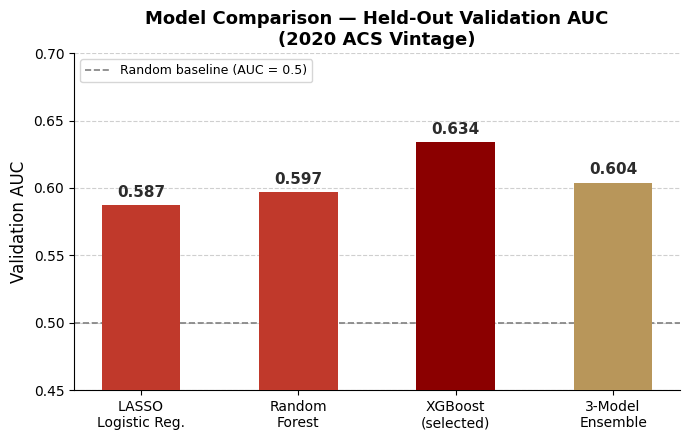

Saved: val_auc_comparison.png


In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

models = ['LASSO\nLogistic Reg.', 'Random\nForest', 'XGBoost\n(selected)', '3-Model\nEnsemble']
val_aucs = [0.587, 0.597, 0.634, 0.604]
colors = ['#C0392B', '#C0392B', '#8B0000', '#B8965A']

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(models, val_aucs, color=colors, width=0.5, zorder=3)

# Baseline reference line
ax.axhline(y=0.5, color='gray', linewidth=1.2, linestyle='--', zorder=2, label='Random baseline (AUC = 0.5)')

# Value labels on bars
for bar, val in zip(bars, val_aucs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.004,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold', color='#2C2C2C')

ax.set_ylim(0.45, 0.70)
ax.set_ylabel('Validation AUC', fontsize=12)
ax.set_title('Model Comparison — Held-Out Validation AUC\n(2020 ACS Vintage)', fontsize=13, fontweight='bold')
ax.yaxis.grid(True, linestyle='--', alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('val_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: val_auc_comparison.png")

In [24]:
from google.colab import files
files.download('val_auc_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>